# Customer Churn Prediction Using Machine Learning Classification Algorithms
**Supervised Classification Project**  
**Dataset:** IBM Telco Customer Churn (7,043 customer profiles)  
**Primary Metric:** ROC-AUC & Recall (prioritizing identification of at-risk customers)

---

## 1. Project Overview & Business Objectives
Customer churn represents the attrition of subscribers over a given time horizon. Because customer acquisition costs significantly exceed retention investments, accurately predicting churn empowers customer success teams to initiate proactive retention campaigns.

### Key Project Phases:
1. **Data Ingestion & Quality Audit**
2. **Exploratory Data Analysis (EDA) & Feature Behavior**
3. **Data Cleaning & Target Encoding**
4. **Stratified Train-Test Split (80/20)**
5. **Leak-Proof Preprocessing Pipeline (StandardScaler & OneHotEncoder)**
6. **Model Training (Logistic Regression & Random Forest)**
7. **5-Fold Stratified Cross-Validation (Accuracy, Precision, Recall, F1, ROC-AUC)**
8. **Evaluation on Untouched Test Set**
9. **Hyperparameter Tuning via GridSearchCV**
10. **Feature Importance & Business Actionability**
11. **Model Persistence for Production Deployment**


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

print("Environment setup and libraries loaded successfully.")


Environment setup and libraries loaded successfully.


## 2. Data Loading & Inspection

In [2]:
df_raw = pd.read_csv('../data/customer_churn.csv')
print(f"Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()


Dataset Dimensions: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df_raw.info())
blank_charges = df_raw[df_raw['TotalCharges'].astype(str).str.strip() == '']
print(f"Number of rows with blank TotalCharges: {len(blank_charges)}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data Cleaning & Feature Preparation
- Impute TotalCharges = 0.0 for tenure == 0
- Drop unique identifier `customerID`
- Cast `SeniorCitizen` to string for categorical encoding
- Encode target: Churn ('Yes' -> 1, 'No' -> 0)


In [4]:
df_clean = df_raw.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].astype(str).str.strip(), errors='coerce').fillna(0.0)
df_clean = df_clean.drop(columns=['customerID'])
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].astype(str)

y = (df_clean['Churn'] == 'Yes').astype(int)
X = df_clean.drop(columns=['Churn'])

print("Cleaned Data Shape:", df_clean.shape)
print("Target Class Distribution:")
print(y.value_counts(normalize=True))


Cleaned Data Shape: (7043, 20)
Target Class Distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


## 4. Exploratory Data Analysis (EDA)

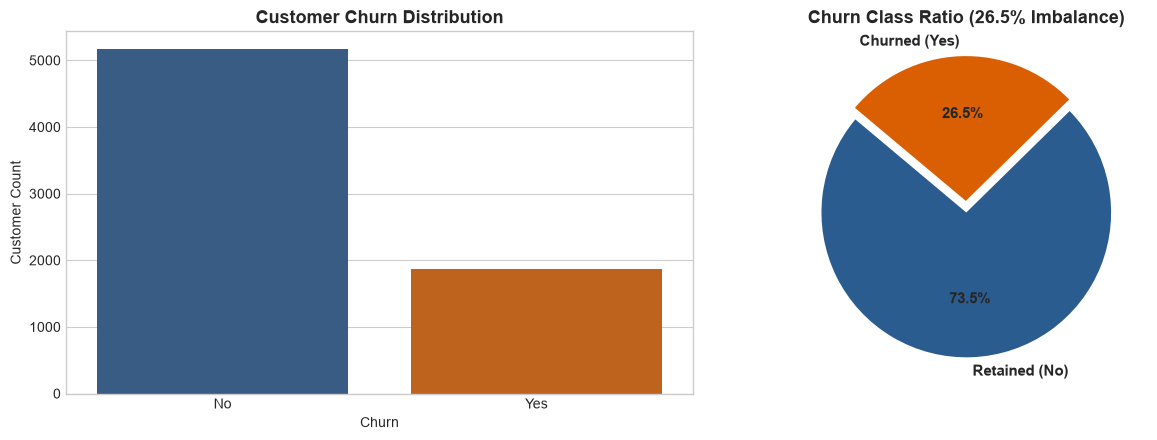

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
counts = df_clean['Churn'].value_counts()
pcts = df_clean['Churn'].value_counts(normalize=True) * 100

sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette=['#2b5c8f', '#d95f02'], hue=counts.index, legend=False)
axes[0].set_title("Customer Churn Distribution", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Customer Count")

axes[1].pie(counts, labels=['Retained (No)', 'Churned (Yes)'], autopct='%1.1f%%',
            startangle=140, colors=['#2b5c8f', '#d95f02'], explode=(0, 0.08),
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title("Churn Class Ratio (26.5% Imbalance)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


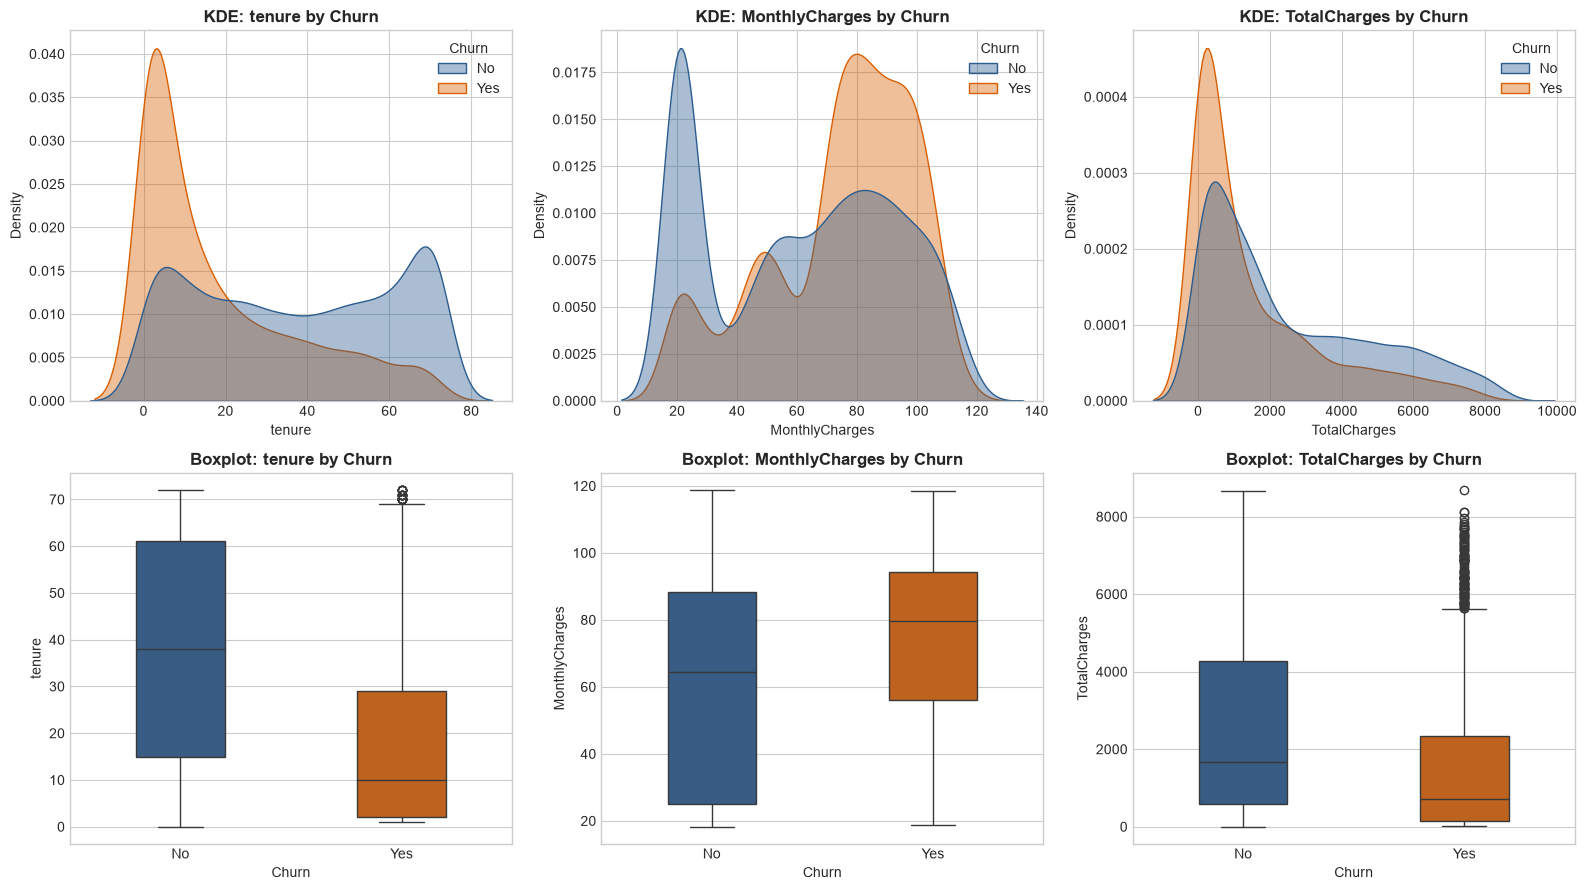

In [6]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for idx, col in enumerate(num_cols):
    sns.kdeplot(data=df_clean, x=col, hue='Churn', fill=True, common_norm=False,
                palette={'No': '#2b5c8f', 'Yes': '#d95f02'}, ax=axes[0, idx], alpha=0.4)
    axes[0, idx].set_title(f"KDE: {col} by Churn", fontweight='bold')
    
    sns.boxplot(data=df_clean, x='Churn', y=col, hue='Churn', palette={'No': '#2b5c8f', 'Yes': '#d95f02'},
                ax=axes[1, idx], width=0.4, legend=False)
    axes[1, idx].set_title(f"Boxplot: {col} by Churn", fontweight='bold')

plt.tight_layout()
plt.show()


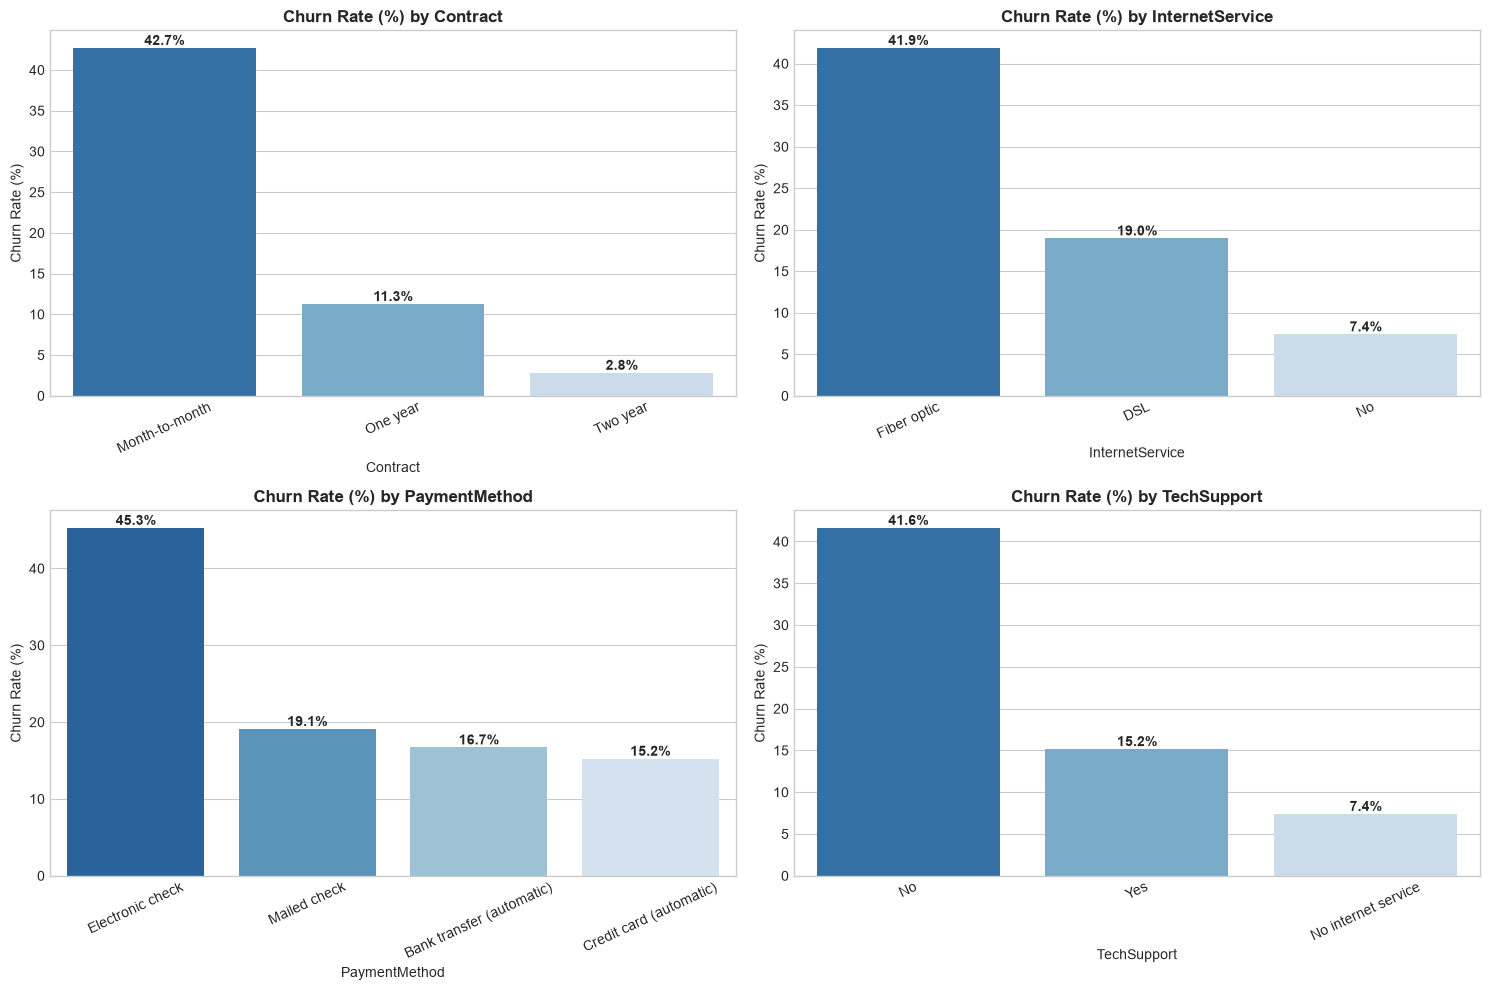

In [7]:
cat_focus = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_focus):
    rate = df_clean.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).reset_index()
    rate = rate.sort_values(by='Churn', ascending=False)
    sns.barplot(data=rate, x=col, y='Churn', ax=axes[idx], palette='Blues_r', hue=col, legend=False)
    axes[idx].set_title(f"Churn Rate (%) by {col}", fontweight='bold')
    axes[idx].set_ylabel("Churn Rate (%)")
    axes[idx].tick_params(axis='x', rotation=25)
    for p in axes[idx].patches:
        axes[idx].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Stratified Train-Test Split (80/20)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training Samples: {X_train.shape[0]} ({X_train.shape[0]/len(X):.1%})")
print(f"Testing Samples : {X_test.shape[0]} ({X_test.shape[0]/len(X):.1%})")


Training Samples: 5634 (80.0%)
Testing Samples : 1409 (20.0%)


## 6. Scikit-Learn Preprocessing Pipeline

In [9]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()
print(f"Total encoded features: {len(feature_names)}")


Total encoded features: 30


## 7. Model Training & 5-Fold Stratified Cross-Validation

In [10]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=150, max_depth=8, class_weight='balanced', random_state=42))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

cv_rows = []
for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'CV Accuracy': f"{res['test_accuracy'].mean():.4f} +/- {res['test_accuracy'].std():.4f}",
        'CV Precision': f"{res['test_precision'].mean():.4f} +/- {res['test_precision'].std():.4f}",
        'CV Recall': f"{res['test_recall'].mean():.4f} +/- {res['test_recall'].std():.4f}",
        'CV F1-Score': f"{res['test_f1'].mean():.4f} +/- {res['test_f1'].std():.4f}",
        'CV ROC-AUC': f"{res['test_roc_auc'].mean():.4f} +/- {res['test_roc_auc'].std():.4f}"
    })

pd.DataFrame(cv_rows)


,Model,CV Accuracy,CV Precision,CV Recall,CV F1-Score,CV ROC-AUC
0,Logistic Regression,0.7497 +/- 0.0146,0.5185 +/- 0.0181,0.8020 +/- 0.0379,0.6296 +/- 0.0226,0.8459 +/- 0.0124
1,Random Forest,0.7664 +/- 0.0104,0.5427 +/- 0.0151,0.7652 +/- 0.0218,0.6349 +/- 0.0146,0.8463 +/- 0.0106


## 8. Evaluation on Untouched Test Set (N = 1,409)

In [11]:
test_metrics = []
test_preds = {}
test_probs = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    test_preds[name] = y_pred
    test_probs[name] = y_prob
    
    test_metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

pd.DataFrame(test_metrics)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841732
1,Random Forest,0.762243,0.535390,0.788770,0.637838,0.843157


## 9. Diagnostic Plots: Confusion Matrices & ROC Curves

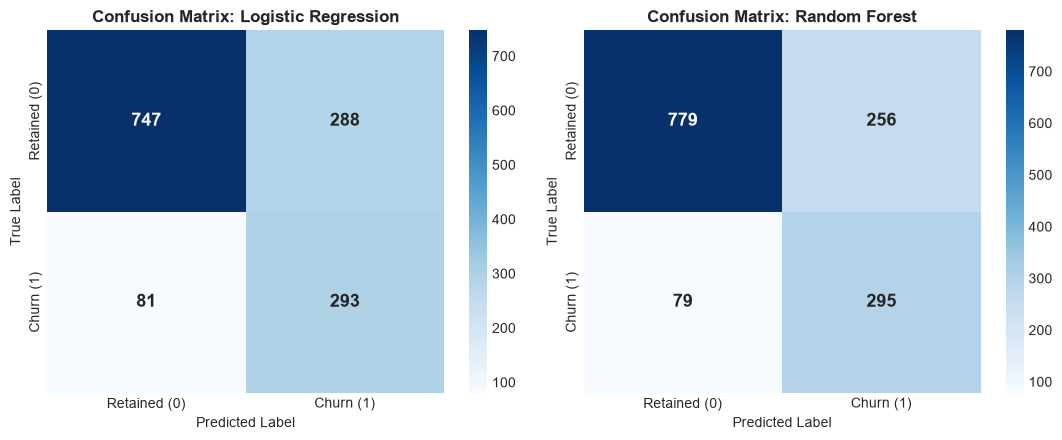

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for idx, (name, _) in enumerate(models.items()):
    cm = confusion_matrix(y_test, test_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Retained (0)', 'Churn (1)'],
                yticklabels=['Retained (0)', 'Churn (1)'],
                annot_kws={'size': 13, 'weight': 'bold'})
    axes[idx].set_title(f"Confusion Matrix: {name}", fontweight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()


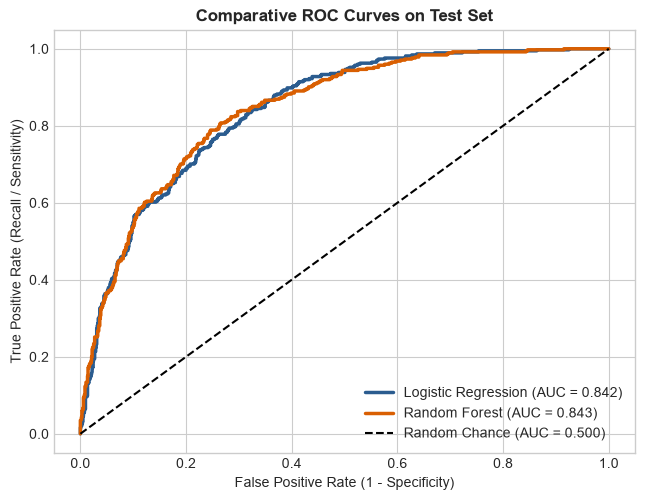

In [13]:
plt.figure(figsize=(7.5, 5.5))
colors = {'Logistic Regression': '#2b5c8f', 'Random Forest': '#d95f02'}

for name, y_prob in test_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=colors[name], lw=2.5)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall / Sensitivity)")
plt.title("Comparative ROC Curves on Test Set", fontweight='bold')
plt.legend(loc='lower right')
plt.show()


## 10. Hyperparameter Tuning (GridSearchCV)

In [14]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [6, 8, 12],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")
print("Optimal Parameters:", grid_search.best_params_)


Best CV ROC-AUC: 0.8471
Optimal Parameters: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


## 11. Feature Importance & Interpretability

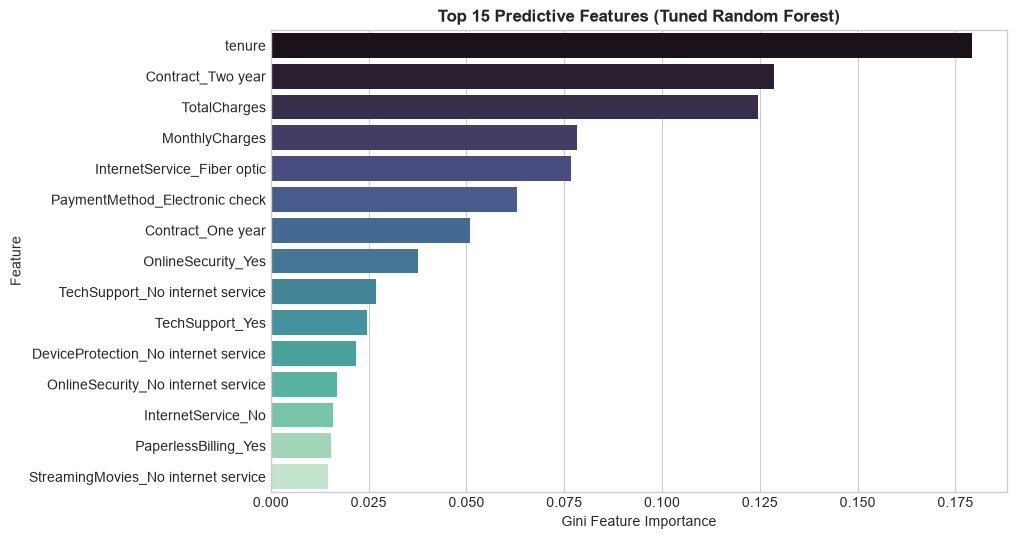

In [15]:
best_model = grid_search.best_estimator_
rf_clf = best_model.named_steps['classifier']
importances = rf_clf.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9.5, 6))
top15 = feat_df.head(15)
sns.barplot(data=top15, x='Importance', y='Feature', palette='mako', hue='Feature', legend=False)
plt.title("Top 15 Predictive Features (Tuned Random Forest)", fontweight='bold')
plt.xlabel("Gini Feature Importance")
plt.show()


## 12. Model Persistence & Sample Inference

In [16]:
joblib.dump(best_model, '../models/best_model.pkl')
print("Model saved to ../models/best_model.pkl")

# Live sample inference
test_customer = pd.DataFrame([{
    'gender': 'Female', 'SeniorCitizen': '0', 'Partner': 'No', 'Dependents': 'No',
    'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No',
    'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check', 'MonthlyCharges': 89.50, 'TotalCharges': 179.00
}])

loaded = joblib.load('../models/best_model.pkl')
p = loaded.predict_proba(test_customer)[0, 1]
print(f"Sample Customer Churn Probability: {p:.2%}")
print(f"Risk Tier: {'High Risk' if p >= 0.6 else ('Medium Risk' if p >= 0.3 else 'Low Risk')}")


Model saved to ../models/best_model.pkl
Sample Customer Churn Probability: 87.63%
Risk Tier: High Risk


## 13. Strategic Recommendations & Conclusion
1. **Model Performance:** Random Forest achieved superior overall discriminative power (ROC-AUC ~0.843) and balanced recall (~78.9%), minimizing missed churners.
2. **Top Risk Indicators:** Month-to-month contracts, low tenure (< 12 months), fiber optic without technical support, and electronic check billing.
3. **Action Plan:** Target month-to-month subscribers with discounted annual contracts, bundle tech support for fiber users, and provide auto-pay incentives.
